In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("customers.csv")

# Show first 5 rows
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [2]:
print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [3]:
# Select important columns
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit model
df['Cluster'] = kmeans.fit_predict(X)

# Show first rows with clusters
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


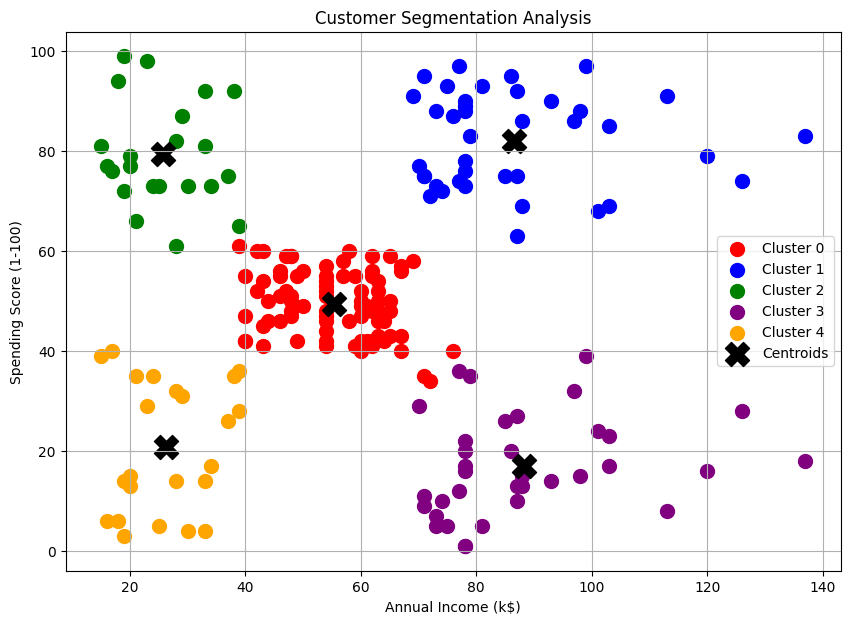

In [10]:
# Better Customer Segmentation Graph

plt.figure(figsize=(10,7))

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(5):
    cluster = df[df['Cluster'] == i]

    plt.scatter(
        cluster['Annual Income (k$)'],
        cluster['Spending Score (1-100)'],
        s=100,
        c=colors[i],
        label=f'Cluster {i}'
    )

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation Analysis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend()
plt.grid(True)

fig = plt.gcf()
fig.savefig("customer_segmentation.png", dpi=300)

plt.show()